# 2. Problems in YAML

A problem for the built-in mass-spring model is a dozen lines of YAML: the chain, the
partition, the local estimators, the unknowns, the sensors, the loads and the time
grid. `pci.solve` builds the system, generates synthetic ground truth and data,
runs the distributed estimation and returns a `Results` object. The
[Configuration](../configuration.md) page lists every key.

In [1]:
import copy

import pci

## The file

In [2]:
print(open("01_four_dof_jacobi_ukf.yaml").read())

# YAML twin of 01_four_dof_jacobi_ukf.py. Solve with:  python 02_solve_from_yaml.py  (or pci.solve("01_four_dof_jacobi_ukf.yaml"))
model: mass_spring_chain
masses: [500, 500, 500, 500]
stiffness: [50000, 50000, 50000, 50000]      # spring i connects DOF i-1 (0 = ground) to DOF i
damping: [300, 300, 300, 300]

subsystems: [[1, 2], [3, 4]]                 # DOF groups -> S1, S2
filters: {S1: ukf, S2: ckf}                  # kf | ekf | ukf | ckf, per subsystem
integrator: {S1: heun, S2: rk4}              # euler | heun | rk4, one name for all or per subsystem
schedule: {type: jacobi, iterations: 1}      # jacobi | gauss_seidel
messages: mean                               # mean (mean_variance is the next step)

unknowns:
  k4: {initial: 30000, std: 50000, process_std: 0.0}

sensors: [a1, a4]                            # a = acceleration, x = displacement, v = velocity
noise_std: 1.0e-3

loads:                                       # external forces per DOF
  1: {type: random, std: 400, se

## Solve it

In [3]:
results = pci.solve("01_four_dof_jacobi_ukf.yaml")
print(results.summary(start=1.0))

mode=estimate  schedule=Jacobi(iterations=1)  steps=5000  runtime=1.41s
[S1]
          x1: final=-0.00245899  std= 3.89e-05  rmse= 0.0001594
          x2: final=-0.00516305  std= 6.28e-05  rmse= 0.0002916
          v1: final=-0.0246719  std= 0.000234  rmse= 0.000898
          v2: final=-0.0409316  std= 0.000378  rmse= 0.001469
[S2]
          x3: final=-0.00653791  std= 0.036  rmse= 0.0003776
          x4: final=-0.00737316  std= 0.036  rmse= 0.0004242
          v3: final=-0.0880728  std= 0.00707  rmse= 0.001448
          v4: final=-0.0545588  std= 0.00707  rmse= 0.001429
          k4: final= 49811.7  std= 67.2  true= 50000  rmse= 186.6
[messages] F_k3


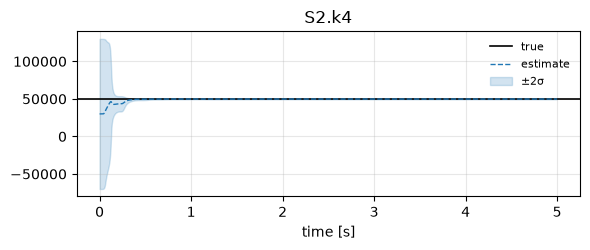

In [4]:
results.plot_parameters();

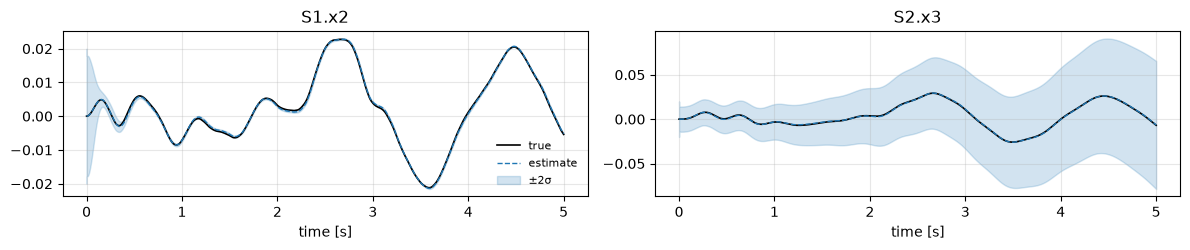

In [5]:
results.plot_states(["S1.x2", "S2.x3"]);

## Override a configuration

`load_config` returns a plain dictionary, so a study over schedules, filters or
partitions is a loop that changes a key and calls `pci.solve` on the copy.

In [6]:
base = pci.load_config("01_four_dof_jacobi_ukf.yaml")
variants = {
    "baseline (jacobi, ukf + ckf)": {},
    "gauss_seidel": {"schedule": "gauss_seidel"},
    "ab2": {"schedule": "ab2"},
    "all ckf": {"filters": "ckf"},
    "jacobi, 2 inner iterations": {"schedule": {"type": "jacobi", "iterations": 2}},
}
print(f"{'variant':<32s}{'k4 final':>10s}{'error %':>9s}{'x3 rmse':>10s}{'time [s]':>9s}")
for label, overrides in variants.items():
    cfg = copy.deepcopy(base)
    cfg.update(overrides)
    res = pci.solve(cfg)
    k4 = res.final("k4")
    print(f"{label:<32s}{k4:>10.1f}{100 * (k4 - 50_000) / 50_000:>+9.2f}{res.rmse(['x3'], start=1.0)['x3']:>10.2e}{res.runtime:>9.1f}")

variant                           k4 final  error %   x3 rmse time [s]


baseline (jacobi, ukf + ckf)       49811.7    -0.38  3.78e-04      1.4


gauss_seidel                       49678.7    -0.64  4.11e-04      1.4


ab2                                49876.7    -0.25  4.47e-04      1.5


all ckf                            49811.7    -0.38  3.78e-04      1.4


jacobi, 2 inner iterations         49876.1    -0.25  4.48e-04      2.7


## Bring your own measurements

Without a `truth` block nothing is simulated; pass the recorded sensor signals as
`measurements={name: array}` instead. The arrays must be sampled on the `time` grid
of the configuration (`n_steps + 1` samples).

In [7]:
chain = pci.MassSpringChain.uniform(4, mass=500.0, k=50_000.0, c=300.0)
loads = {d: {"type": "random", "std": 400.0, "seed": 10 + d} for d in range(1, 5)}
truth = chain.simulate(loads, dt=1e-3, T=5.0)
data = chain.measure(truth, ["a1", "a4"], noise_std=1e-3, seed=3)

cfg = copy.deepcopy(base)
cfg.pop("truth")                                   # no synthetic data: use the arrays below
cfg["loads"] = loads                               # the loads that acted on the real structure
res = pci.solve(cfg, measurements=data)
print(f"k4 from recorded data: {res.final('k4'):.1f}")

k4 from recorded data: 2198.2
